In [15]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from tqdm import tqdm
import seaborn
seaborn.set_style('whitegrid')

# Always run from repo root regardless of notebook location
_REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath("__file__")), ".."))
if os.path.basename(os.getcwd()) == "analysis":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

from utils.checkpoint_info import get_token_count


In [ ]:
def load_results(model_name: str, dataset_name: str = 'fineweb'):
    new_path = os.path.join('results', dataset_name, f'results_{model_name}.npy')
    old_path = os.path.join('results', f'results_{model_name}.npy')
    path = new_path if os.path.exists(new_path) else old_path
    res = np.load(path, allow_pickle=True).item()
    step_nums = sorted(res.keys())
    return res, step_nums


def get_xs_steps(model_name, step_nums):
    return step_nums


def get_xs_tokens(model_name, step_nums):
    return [get_token_count(model_name, s) for s in step_nums]


def _parse_param_count(model_name):
    """Extract parameter count from model name (e.g. 'pythia-70m' -> 70e6, 'OLMo-2-0425-1B' -> 1e9)."""
    name = model_name.lower()
    if 'pythia' in name:
        size_str = model_name.split('pythia-')[-1].split('-deduped')[0]
    elif 'olmo' in name:
        size_str = model_name.split('-')[-1]
    else:
        raise ValueError(f"Cannot extract param count from {model_name}")
    multiplier = 1e6 if size_str[-1].lower() == 'm' else 1e9
    return float(size_str[:-1]) * multiplier


def get_xs_flops(model_name, step_nums):
    num_params = _parse_param_count(model_name)
    return [num_params * s for s in step_nums]


XVAR_FNS = {
    'steps': get_xs_steps,
    'tokens': get_xs_tokens,
    'flops': get_xs_flops,
}

XVAR_LABELS = {
    'steps': 'Steps',
    'tokens': 'Pretraining tokens',
    'flops': 'Flops',
    'isoflops': 'Parameters',
}

YVAR_LABELS = {
    'alpha': r'$\alpha$',
    'rankme': 'RankMe',
}

model_names = [
    'pythia-14m', 'pythia-14m-deduped',
    'pythia-31m', 'pythia-31m-deduped',
    'pythia-70m', 'pythia-70m-deduped',
    'pythia-160m', 'pythia-160m-deduped',
    'pythia-410m', 'pythia-410m-deduped',
    'pythia-1b', 'pythia-1b-deduped',
    'pythia-1.4b', 'pythia-1.4b-deduped',
    'pythia-2.8b', 'pythia-2.8b-deduped',
    'pythia-6.9b', 'pythia-6.9b-deduped',
    'pythia-12b', 'pythia-12b-deduped',
    'OLMo-2-0425-1B',
    'OLMo-2-1124-7B',
]

colors = [
    'turquoise', 'turquoise',
    'cornflowerblue', 'cornflowerblue',
    'dodgerblue', 'dodgerblue',
    'gold', 'gold',
    'lime', 'lime',
    'darkgreen', 'darkgreen',
    'magenta', 'magenta',
    'deeppink', 'deeppink',
    'purple', 'purple',
    'brown', 'brown',
    'blue',
    'red',
]

def plot_model_training(model_name: str, xvar: str = 'steps', yvar: str = 'alpha',
                        dataset_name: str = 'fineweb',
                        color: str = 'k', ls: str = '-', marker: str = 'o'):
    res, step_nums = load_results(model_name, dataset_name=dataset_name)
    xs = XVAR_FNS[xvar](model_name, step_nums)
    ys = [res[s][yvar] for s in step_nums]
    plt.plot(xs, ys, marker=marker, color=color, ls=ls, lw=3, label=f'{model_name}')


def plot_model_training_isoflops(model_name: str, yvar: str = 'alpha',
                                 dataset_name: str = 'fineweb',
                                 marker: str = 'o', max_flops: int = 2e15):
    res, step_nums = load_results(model_name, dataset_name=dataset_name)
    flops_per_step = _parse_param_count(model_name)
    isoflops = np.array([1e13, 5e13, 1e14])
    isoflops_steps = (isoflops / flops_per_step // 1000 * 1000).astype(int)
    plot_steps = [s for s in isoflops_steps if s < max(step_nums) and s > min(step_nums)]
    ys = [res[s][yvar] for s in plot_steps]
    xs = [flops_per_step] * len(ys)
    plot_colors = colors[:len(plot_steps)]
    plt.scatter(xs, ys, marker=marker, color=plot_colors)


100%|██████████| 24/24 [00:00<00:00, 947.22it/s]


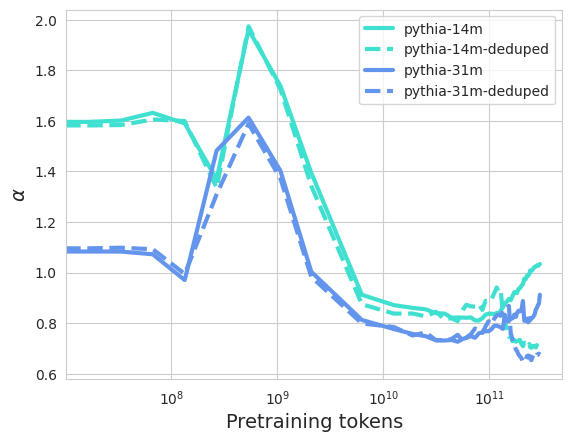

In [ ]:

filter_model_names = [
    'pythia-14m-deduped',
    'pythia-31m-deduped',
    'pythia-70m-deduped',
    # 'pythia-160m-deduped',
    # 'pythia-410m-deduped',
    # 'pythia-1b-deduped',
    # 'pythia-1.4b-deduped',
    # 'pythia-2.8b-deduped',
    # 'pythia-6.9b-deduped',
    # 'pythia-12b-deduped',
    'pythia-14m',
    'pythia-31m',
    # 'pythia-70m',
    # 'pythia-160m',
    # 'pythia-410m',
    # 'pythia-1b',
    # 'pythia-1.4b',
    # 'pythia-2.8b',
    # 'pythia-6.9b',
    # 'pythia-12b',
    # 'OLMo-2-0425-1B',
    # 'OLMo-2-1124-7B',
]


dataset_name = 'fineweb'
xvar = 'tokens' # steps, tokens, flops, isoflops (not tested)
yvar = 'alpha' # alpha, rankme


for midx, model_name in enumerate(tqdm(model_names)):
    if len(filter_model_names) and model_name not in filter_model_names: continue
    color = colors[midx]
    ls = '--' if 'deduped' in model_name else '-'
    marker = '*' if 'deduped' in model_name else 's'
    try:
        if xvar == 'isoflops':
            plot_model_training_isoflops(model_name, yvar=yvar, dataset_name=dataset_name, marker=marker)
        else:
            plot_model_training(model_name, xvar=xvar, yvar=yvar,
                                dataset_name=dataset_name,
                                color=color, ls=ls, marker='')
    except:
        continue

plt.xscale('log')
plt.xlabel(XVAR_LABELS[xvar], fontsize=14)
plt.ylabel(YVAR_LABELS.get(yvar, yvar), fontsize=14)
plt.legend()
plt.show()

